python 3.11, miniconda, cuda 12.8
ffmpeg==8.0.1
torch==2.9.0
torchcodec==0.9.1

```bash
conda install conda-forge::ffmpeg==8.0.1
ffmpeg -decoders | grep -i nvidia
```

```bash
pip install torch==2.9.0 torchvision==0.24.0 torchaudio==2.9.0 --index-url https://download.pytorch.org/whl/cu128
pip install torchcodec==0.9.1 --index-url=https://download.pytorch.org/whl/cu128
```


In [1]:
import time
import json
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchaudio
import torchaudio.transforms as T
import tqdm
import matplotlib.pyplot as plt
from thop import profile, clever_format
from typing import Optional
from torchaudio import functional as F

### Melbanks

In [3]:
class LogMelFilterBanks(nn.Module):
    def __init__(
            self,
            n_fft: int = 400,
            samplerate: int = 16000,
            hop_length: int = 160,
            n_mels: int = 80,
            pad_mode: str = 'reflect',
            power: float = 2.0,
            normalize_stft: bool = False,
            onesided: bool = True,
            center: bool = True,
            return_complex: bool = True,
            f_min_hz: float = 0.0,
            f_max_hz: Optional[float] = None,
            norm_mel: Optional[str] = None,
            mel_scale: str = 'htk'
        ):
        super(LogMelFilterBanks, self).__init__()
        self.n_fft = n_fft
        self.samplerate = samplerate
        self.window_length = n_fft
        self.window = torch.hann_window(self.window_length)

        self.hop_length = hop_length
        self.n_mels = n_mels
        self.center = center
        self.return_complex = return_complex
        self.onesided = onesided
        self.normalize_stft = normalize_stft
        self.pad_mode = pad_mode
        self.power = power

        self.f_min_hz = f_min_hz
        self.f_max_hz = f_max_hz if f_max_hz is not None else samplerate / 2
        self.norm_mel = norm_mel
        self.mel_scale = mel_scale

        self.mel_fbanks = self._init_melscale_fbanks()

    def _init_melscale_fbanks(self):
        n_freqs = self.n_fft // 2 + 1 if self.onesided else self.n_fft
        return F.melscale_fbanks(
            n_freqs=n_freqs,
            f_min=self.f_min_hz,
            f_max=self.f_max_hz,
            n_mels=self.n_mels,
            sample_rate=self.samplerate,
            norm=self.norm_mel,
            mel_scale=self.mel_scale
        )

    def spectrogram(self, x):
        window = self.window.to(x.device)
        stft = torch.stft(
            x,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.window_length,
            window=window,
            center=self.center,
            pad_mode=self.pad_mode,
            normalized=self.normalize_stft,
            onesided=self.onesided,
            return_complex=self.return_complex
        )
        if self.return_complex:
            power_spec = stft.abs() ** self.power
        else:
            power_spec = (stft[..., 0] ** 2 + stft[..., 1] ** 2) ** (self.power / 2)
        return power_spec

    def forward(self, x):
        """
        Args:
            x (Torch.Tensor): Tensor of audio of dimension (batch, time), audiosignal
        Returns:
            Torch.Tensor: Tensor of log mel filterbanks of dimension (batch, n_mels, n_frames),
                where n_frames is a function of the window_length, hop_length and length of audio
        """
        spec = self.spectrogram(x)                     # (batch, freq, time)
        mel_fbanks = self.mel_fbanks.to(x.device)      # (freq, n_mels)
        mel_spec = torch.einsum("bft,fm->bmt", spec, mel_fbanks)  # (batch, n_mels, time)
        eps = 1e-6
        log_mel = torch.log(mel_spec + eps)
        return log_mel

### Dataset

In [4]:
import os

In [5]:
class YesNoDataset(Dataset):
    """Загрузил датасет с kaggle и работал уже с ним, так как SPEECHCOMMANDS dataloader уходил в какой-то бесконечный цикл"""
    def __init__(self, root, subset='training', target_length=16000):
        self.root = root
        self.subset = subset
        self.target_length = target_length

        if subset == 'validation':
            list_file = os.path.join(root, 'validation_list.txt')
        elif subset == 'testing':
            list_file = os.path.join(root, 'testing_list.txt')
        else:  # training
            val_file = os.path.join(root, 'validation_list.txt')
            test_file = os.path.join(root, 'testing_list.txt')
            with open(val_file, 'r') as f:
                val_set = set(line.strip() for line in f if line.strip())
            with open(test_file, 'r') as f:
                test_set = set(line.strip() for line in f if line.strip())
            self.exclude = val_set | test_set
            list_file = None

        if list_file is not None:
            with open(list_file, 'r') as f:
                self.paths = [line.strip() for line in f if line.strip()]
        else:
            self.paths = []
            for label_folder in ['yes', 'no']:
                folder = os.path.join(root, label_folder)
                if not os.path.isdir(folder):
                    continue
                for fname in os.listdir(folder):
                    if not fname.endswith('.wav'):
                        continue
                    rel_path = os.path.join(label_folder, fname)
                    if rel_path not in self.exclude:
                        self.paths.append(rel_path)

        self.label_map = {'yes': 0, 'no': 1}

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        rel_path = self.paths[idx]
        full_path = os.path.join(self.root, rel_path)
        waveform, sample_rate = torchaudio.load(full_path)  # shape (1, T)
        waveform = waveform.squeeze(0)

        # to target_length
        current_len = waveform.size(0)
        if current_len < self.target_length:
            # zeros at end
            padding = self.target_length - current_len
            waveform = torch.nn.functional.pad(waveform, (0, padding))
        elif current_len > self.target_length:
            waveform = waveform[:self.target_length]

        label_str = rel_path.split(os.sep)[0]
        label = self.label_map[label_str]
        return waveform, label

### NN

In [6]:
class SimpleCNN1D(nn.Module):
    def __init__(self, n_mels=80, groups=1):
        super().__init__()
        # LogMelFilterBanks as feature extractor
        self.logmel = LogMelFilterBanks(
            n_fft=400,
            samplerate=16000,
            hop_length=160,
            n_mels=n_mels,
            f_max_hz=8000,
            norm_mel='slaney',
            mel_scale='htk'
        )
        # CNN backbone
        self.conv1 = nn.Conv1d(n_mels, 32, kernel_size=3, stride=1, padding=1, groups=groups)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1, groups=groups)
        self.bn2 = nn.BatchNorm1d(64)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1, groups=groups)
        self.bn3 = nn.BatchNorm1d(128)

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, 2)

    def forward(self, x):
        x = self.logmel(x)            # (batch, n_mels, n_frames)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.global_pool(x)       # (batch, 128, 1)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x

### Compute utils

In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def compute_flops(model, input_tensor):
    flops, params = profile(model, inputs=(input_tensor,), verbose=False)
    return flops, params

### Train utils

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for batch in tqdm.tqdm(loader, desc='Training', leave=False):
        waveforms, labels = batch
        waveforms, labels = waveforms.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(waveforms)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * waveforms.size(0)
    return total_loss / len(loader.dataset)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in tqdm.tqdm(loader, desc='Validation', leave=False):
            waveforms, labels = batch
            waveforms, labels = waveforms.to(device), labels.to(device)
            outputs = model(waveforms)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * waveforms.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

def test(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for waveforms, labels in tqdm.tqdm(loader, desc='Testing'):
            waveforms, labels = waveforms.to(device), labels.to(device)
            outputs = model(waveforms)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

### Plots

In [9]:
def plot_results(results, best_n_mels):
    # train loss - diff n_mels (groups=1)
    plt.figure(figsize=(10, 6))
    for (n_mels, groups), data in results.items():
        if groups == 1:
            plt.plot(data['train_losses'], label=f'n_mels={n_mels}')
    plt.xlabel('Epoch')
    plt.ylabel('Train Loss')
    plt.title('Train Loss vs. n_mels (groups=1)')
    plt.legend()
    plt.grid(True)
    plt.savefig('train_loss_vs_nmels.png')
    plt.show()

    # accuracy vs n_mels
    n_mels_list = [20, 40, 80]
    test_accs = [results[(nm, 1)]['test_acc'] for nm in n_mels_list if (nm, 1) in results]
    plt.figure()
    plt.plot(n_mels_list, test_accs, marker='o')
    plt.xlabel('n_mels')
    plt.ylabel('Test Accuracy')
    plt.title('Test Accuracy vs. n_mels (groups=1)')
    plt.grid(True)
    plt.savefig('test_acc_vs_nmels.png')
    plt.show()

    # groups exp
    groups_list = [1, 2, 4, 8, 16]
    epoch_times_avg = []
    params_list = []
    flops_list = []
    test_accs_groups = []
    for g in groups_list:
        key = (best_n_mels, g)
        if key in results:
            d = results[key]
            epoch_times_avg.append(sum(d['epoch_times']) / len(d['epoch_times']))
            params_list.append(d['params'])
            flops_list.append(d['flops'] / 1e6)  # in MFLOPs
            test_accs_groups.append(d['test_acc'])

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # epoch time vs groups
    axs[0,0].plot(groups_list, epoch_times_avg, marker='s')
    axs[0,0].set_xlabel('groups')
    axs[0,0].set_ylabel('Avg Epoch Time (s)')
    axs[0,0].set_title('Training Time vs groups')
    axs[0,0].grid(True)

    # params vs groups
    axs[0,1].plot(groups_list, params_list, marker='^')
    axs[0,1].set_xlabel('groups')
    axs[0,1].set_ylabel('Number of Parameters')
    axs[0,1].set_title('Model Parameters vs groups')
    axs[0,1].grid(True)

    # FLOPs vs groups
    axs[1,0].plot(groups_list, flops_list, marker='d')
    axs[1,0].set_xlabel('groups')
    axs[1,0].set_ylabel('FLOPs (mil)')
    axs[1,0].set_title('FLOPs vs groups')
    axs[1,0].grid(True)

    # accuracy vs groups (test)
    axs[1,1].plot(groups_list, test_accs_groups, marker='o')
    axs[1,1].set_xlabel('groups')
    axs[1,1].set_ylabel('Test Accuracy')
    axs[1,1].set_title('Test Accuracy vs groups')
    axs[1,1].grid(True)

    plt.tight_layout()
    plt.savefig('groups_experiments.png')
    plt.show()

### Pipe

In [10]:
def run_experiment(n_mels, groups, device, root, log_file, results_dict, checkpoint_dir='checkpoints'):
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    print(f"\n=== Running experiment: n_mels={n_mels}, groups={groups} ===")
    train_set = YesNoDataset(root=root, subset='training', target_length=16000)
    val_set   = YesNoDataset(root=root, subset='validation', target_length=16000)
    test_set  = YesNoDataset(root=root, subset='testing', target_length=16000)

    train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2)

    model = SimpleCNN1D(n_mels=n_mels, groups=groups).to(device)

    sample_input = torch.randn(1, 16000).to(device)
    flops, params = compute_flops(model, sample_input)
    param_count = count_parameters(model)
    print(f"Parameters: {param_count:,} | FLOPs: {flops:,}")

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    num_epochs = 15
    train_losses = []
    val_accuracies = []
    epoch_times = []

    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        epoch_time = time.time() - start_time

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = model.state_dict().copy()
            # checkpoint
            checkpoint_path = os.path.join(checkpoint_dir, f"best_model_nmels{n_mels}_groups{groups}.pt")
            torch.save({
                'epoch': epoch,
                'model_state_dict': best_model_state,
                'val_acc': val_acc,
                'val_loss': val_loss,
                'n_mels': n_mels,
                'groups': groups
            }, checkpoint_path)

        train_losses.append(train_loss)
        val_accuracies.append(val_acc)
        epoch_times.append(epoch_time)

        print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | Time: {epoch_time:.2f}s")
        with open(log_file, 'a') as f:
            f.write(f"{n_mels},{groups},{epoch},{train_loss:.4f},{val_acc:.4f},{epoch_time:.2f}\n")

    model.load_state_dict(best_model_state)
    test_acc = test(model, test_loader, device)
    print(f"Best epoch: {best_epoch} | Best Val Acc: {best_val_acc:.4f} | Test Acc: {test_acc:.4f}")

    summary_file = 'best_epoch_summary.csv'
    header = not os.path.exists(summary_file)
    with open(summary_file, 'a') as f:
        if header:
            f.write('n_mels,groups,best_epoch,best_val_acc,test_acc,parameters,flops\n')
        f.write(f"{n_mels},{groups},{best_epoch},{best_val_acc:.4f},{test_acc:.4f},{param_count},{flops}\n")

    results_dict[(n_mels, groups)] = {
        'train_losses': train_losses,
        'val_accuracies': val_accuracies,
        'epoch_times': epoch_times,
        'test_acc': test_acc,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch,
        'params': param_count,
        'flops': flops
    }
    return results_dict

### Startup

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [12]:
log_file = 'experiment_log.csv'

with open(log_file, 'w') as f:
    f.write('n_mels,groups,epoch,train_loss,val_acc,epoch_time\n')

results = {}

In [13]:
dataset_root = './dataset'

In [14]:
for n_mels in [20, 40, 80]:
    results = run_experiment(n_mels, groups=1, device=device, root=dataset_root,
                                 log_file=log_file, results_dict=results)


=== Running experiment: n_mels=20, groups=1 ===
Parameters: 33,570 | FLOPs: 1,155,968.0


Epoch  1 | Train Loss: 0.2244 | Val Acc: 0.9699 | Time: 10.58s


Epoch  2 | Train Loss: 0.1192 | Val Acc: 0.7345 | Time: 12.61s


Epoch  3 | Train Loss: 0.0850 | Val Acc: 0.9755 | Time: 9.88s


Epoch  4 | Train Loss: 0.0678 | Val Acc: 0.9736 | Time: 12.46s


...

Epoch 13 | Train Loss: 0.0435 | Val Acc: 0.9397 | Time: 9.51s


Epoch 14 | Train Loss: 0.0363 | Val Acc: 0.9812 | Time: 12.10s


Epoch 15 | Train Loss: 0.0323 | Val Acc: 0.9793 | Time: 11.98s


Testing: 100%|██████████| 8/8 [00:01<00:00,  5.27it/s]

Best epoch: 9 | Best Val Acc: 0.9812 | Test Acc: 0.9705


In [15]:
n_mels = 80
for groups in [2, 4, 8, 16]:
    results = run_experiment(n_mels, groups=groups, device=device, root=dataset_root,
                                log_file=log_file, results_dict=results)


=== Running experiment: n_mels=80, groups=2 ===
Parameters: 20,130 | FLOPs: 889,088.0


Epoch  1 | Train Loss: 0.2945 | Val Acc: 0.8550 | Time: 12.26s


Epoch  2 | Train Loss: 0.1435 | Val Acc: 0.6234 | Time: 9.76s


Epoch  3 | Train Loss: 0.1110 | Val Acc: 0.7759 | Time: 12.23s


Epoch  4 | Train Loss: 0.0836 | Val Acc: 0.9341 | Time: 12.17s


...

Epoch 13 | Train Loss: 0.1459 | Val Acc: 0.9699 | Time: 9.61s


Epoch 14 | Train Loss: 0.1409 | Val Acc: 0.9718 | Time: 12.09s


Epoch 15 | Train Loss: 0.1331 | Val Acc: 0.9605 | Time: 9.63s


Testing: 100%|██████████| 8/8 [00:01<00:00,  5.16it/s]

Best epoch: 14 | Best Val Acc: 0.9718 | Test Acc: 0.9567


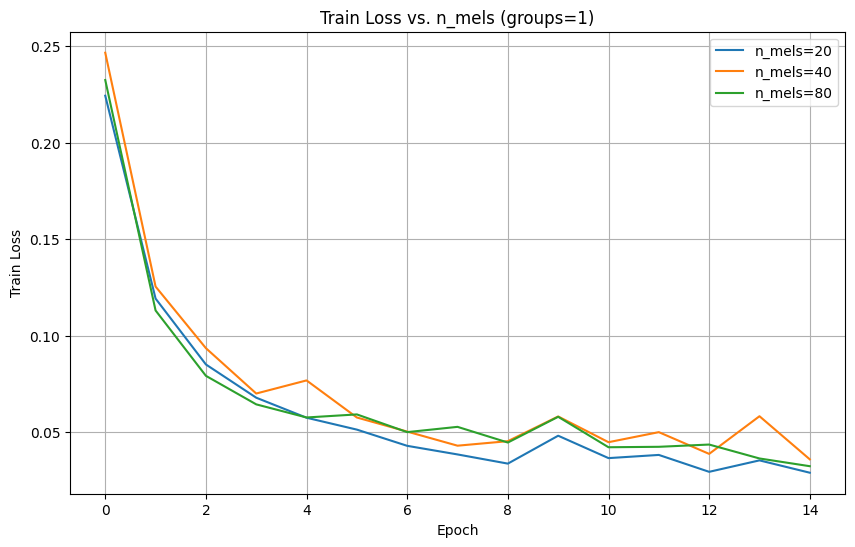

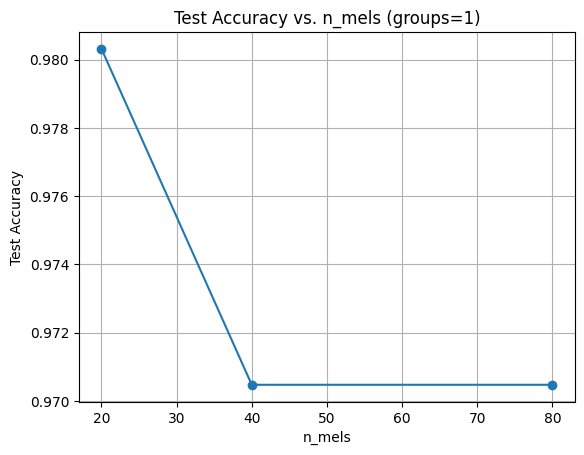

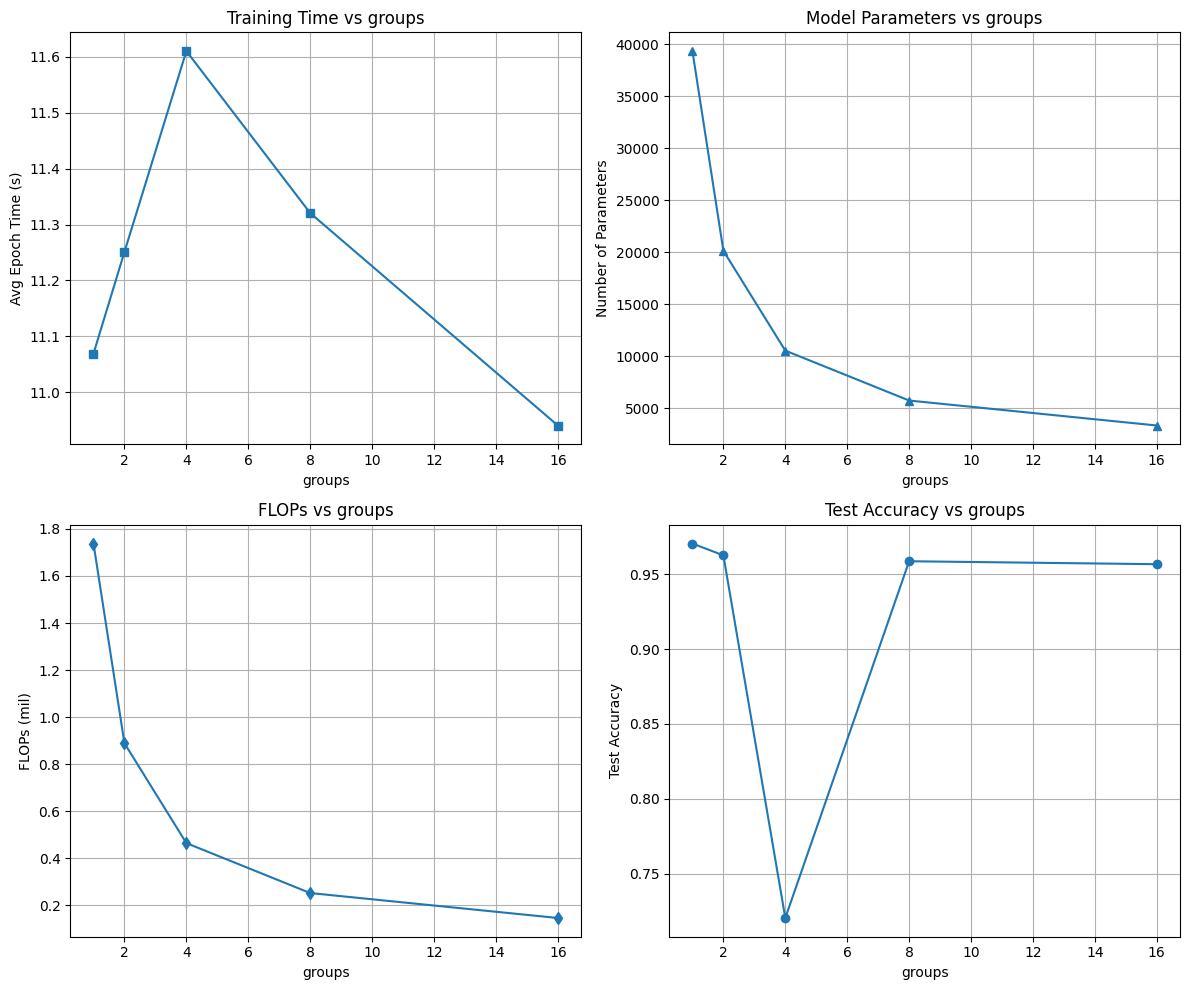

In [16]:
plot_results(results, n_mels)